In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from src.visualize import LossVisualizer

from src.models.mlp import MLP

from src.utils import init_dataloader
from src.train import train
from src.valid import valid

from src.visualize import calc_grid_loss
from src.visualize import LossVisualizer

from src.utils import create_losses_func
from src.calc_delta import DeltaCalculator
from src.calc_delta_visualize import DeltaCalcVisualizer

import numpy as np

from torchvision import transforms

import torch
import torch.nn as nn


DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
transform = transforms.Compose([transforms.ToTensor(),
                               transforms.Normalize((0.5,), (0.5,))])

loader = init_dataloader(
    dataset_name='MNIST',
    transform=transform,
    batch_size=64,
    dataset_load_path='data/',
    train_mode=True,
    size = 64*(10000//64)
)

In [4]:
model = MLP([784, 128, 128, 128, 10]).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr = 3e-4)
criterion = nn.CrossEntropyLoss()

model, losses = train(
    model,
    optimizer,
    criterion,
    loader,
    10,
    DEVICE
)

Train loop:   0%|          | 0/10 [00:00<?, ?it/s]

In [5]:

#grid_step = 0.25
#direction_norm = 20
#losses_func = create_losses_func(loader, criterion)
#vis = LossVisualizer(grid_step=grid_step, direction_norm=direction_norm)
#vis.initialize_grid_loss(model, losses_func, )

In [6]:

delta_calc = DeltaCalculator(model, loader, criterion)

In [7]:

d_vis = DeltaCalcVisualizer(model, loader, criterion)

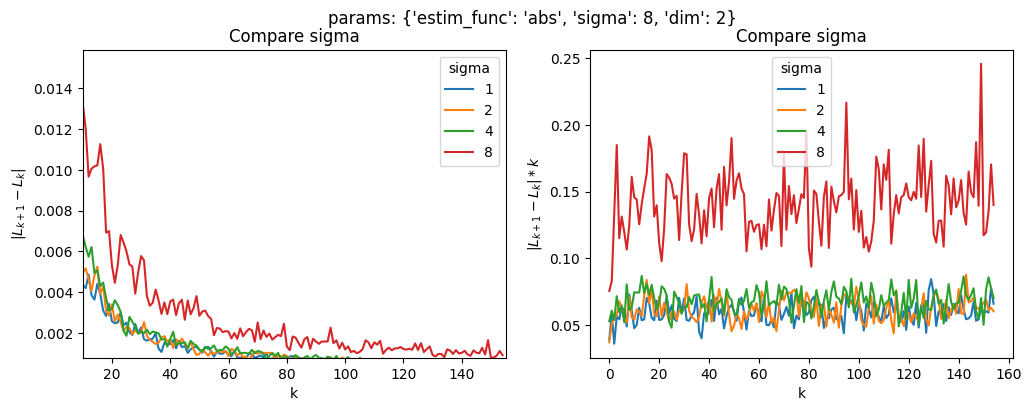

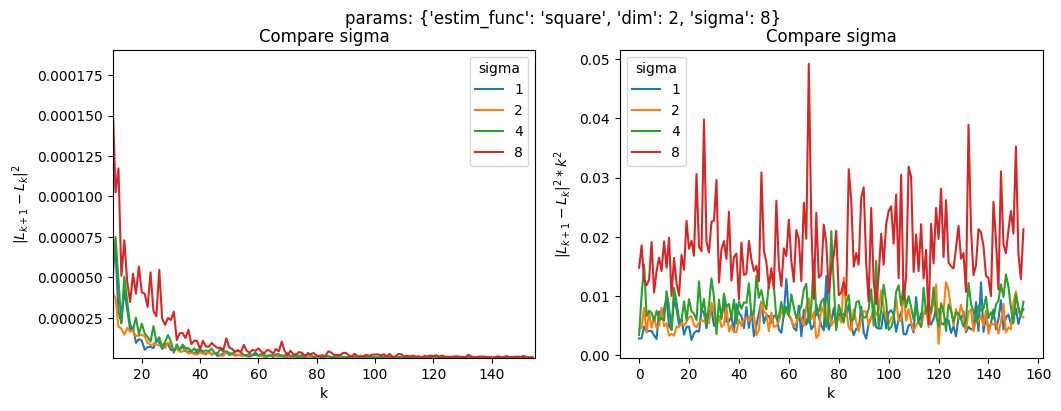

In [18]:
d_vis.compare_params(
    'random-subspace-proj',
    {'estim_func':'abs', 'dim':2},
    'sigma',
    [1, 2, 4, 8],
    num_samples=32,
    begin=10
)
d_vis.compare_params(
    'random-subspace-proj',
    {'estim_func':'square', 'dim':2},
    'sigma',
    [1, 2, 4, 8],
    num_samples=32,
    begin=10
)

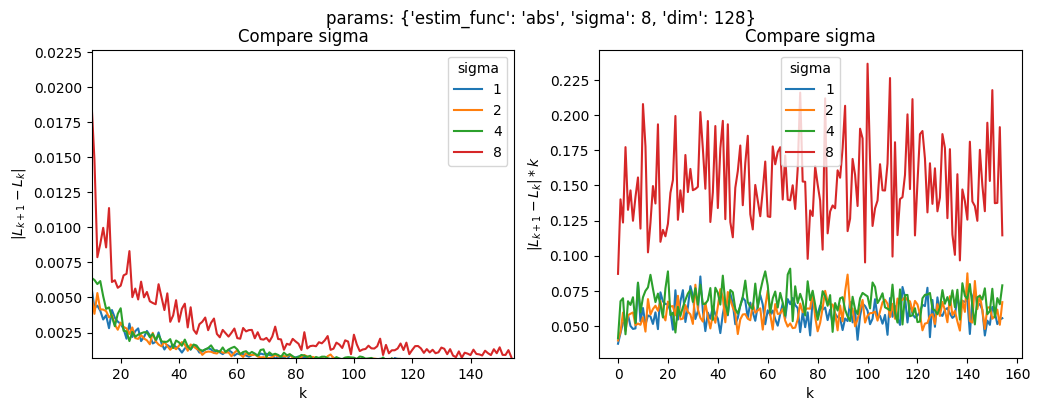

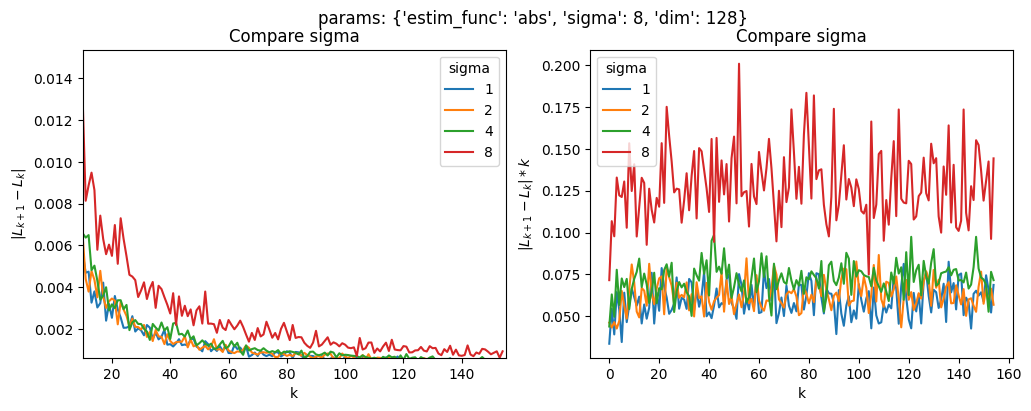

In [16]:
d_vis.compare_params(
    'random-subspace-proj',
    {'estim_func':'abs', 'sigma':4, 'dim':128},
    'sigma',
    [1, 2, 4, 8],
    num_samples=32,
    begin=10
)
d_vis.compare_params(
    'random-subspace-proj',
    {'estim_func':'abs', 'sigma':4, 'dim':128},
    'sigma',
    [1, 2, 4, 8],
    num_samples=32,
    begin=10
)

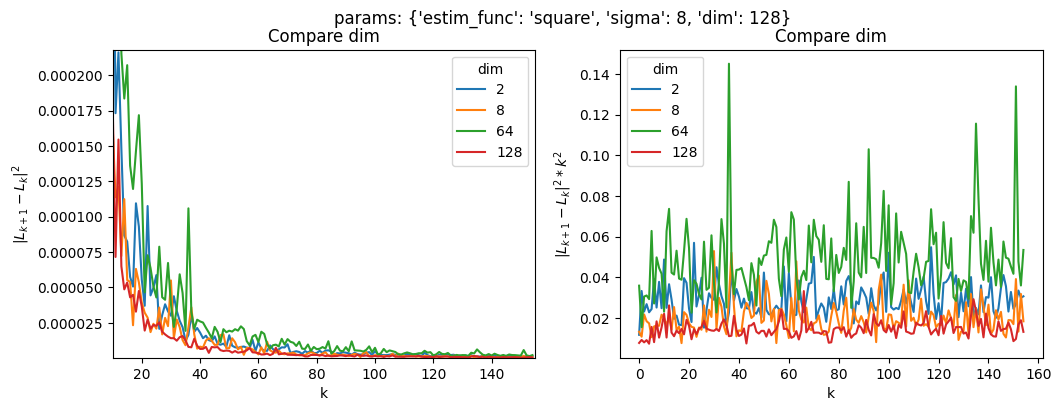

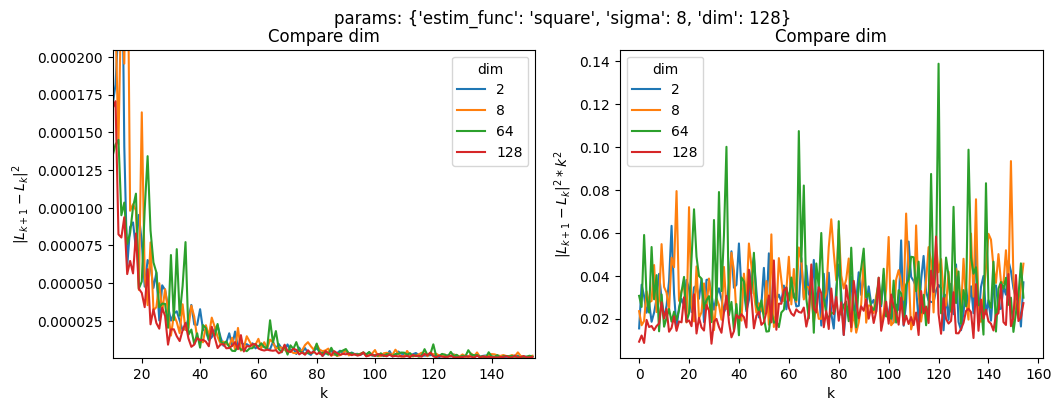

In [17]:
d_vis.compare_params(
    'random-subspace-proj',
    {'estim_func':'square', 'sigma':8},
    'dim',
    [2, 8, 64, 128],
    num_samples=64,
    begin = 10
)
d_vis.compare_params(
    'random-subspace-proj',
    {'estim_func':'square', 'sigma':8},
    'dim',
    [2, 8, 64, 128],
    num_samples=64,
    begin = 10
)